# Skin Cancer Detection (Benign vs Malignant) - Improved Pipeline

**Original notebook me jo problems thi (aur ab fix hain):**

| # | Problem | Fix |
|---|---------|-----|
| 1 | `X_train_split`, `X_val_split`, `X_test_normalized` kabhi define hi nahi hue (code crash) | Clean `tf.data` pipeline, split properly defined |
| 2 | Saari images RAM me load (`np.array`) | Memory-efficient `tf.data` (disk se stream) |
| 3 | ResNet50 par sirf `/255` (galat preprocessing) | Har backbone ka sahi preprocessing |
| 4 | ResNet50 sirf frozen, fine-tuning nahi | 2-stage training: head train, phir fine-tune |
| 5 | ResNet checkpoint `best_cnn_model.h5` overwrite kar raha tha | Har model ka alag checkpoint |
| 6 | Sirf accuracy / weighted metrics | Accuracy, Precision, **Recall (Sensitivity)**, Specificity, F1, ROC-AUC, PR-AUC, MCC |
| 7 | Koi hyperparameter tuning nahi | **Keras Tuner** (units, dropout, lr, label smoothing) |
| 8 | Sirf 2 models | + **EfficientNetV2-S**, + **DenseNet121**, + **Ensemble** |
| 9 | Threshold fixed 0.5 | Validation par **threshold tuning** (F1 / high-recall) |
| 10 | Koi explainability nahi | **Grad-CAM** (model kahan dekh raha hai) |
| 11 | Koi TTA nahi | **Test-Time Augmentation** |
| 12 | Class imbalance ignore | **Class weights** |
| 13 | EDA bohat basic tha | **Full EDA**: image stats, duplicate/leakage check, color/brightness/sharpness, statistical test, PCA |

**Notebook order:** Setup -> Data + **EDA** -> Pipeline -> Helpers -> Custom CNN -> ResNet50V2 -> EfficientNetV2-S (tuned) -> DenseNet121 -> TTA -> Ensemble -> Threshold tuning -> Comparison -> Grad-CAM -> Save + Inference

> Medical note: yeh research/learning project hai, doctor ka replacement nahi.

# 1. Setup

## 1.1 Install extra package (Keras Tuner)

## 1.2 Imports

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             average_precision_score, matthews_corrcoef,
                             balanced_accuracy_score, roc_curve, precision_recall_curve)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

import keras_tuner as kt

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

print('TensorFlow :', tf.__version__)
print('Keras      :', keras.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))

TensorFlow : 2.21.0
Keras      : 3.15.1
GPU        : []


## 1.3 Configuration (yahan apni settings change karo)

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED)

# ---- DATA PATH: apna path yahan likho (folder ke andar train/ aur test/ hon) ----
DATA_DIR = r'C:\Users\hp\Desktop\archive (2)\data'
# Kaggle example: DATA_DIR = '/kaggle/input/skin-cancer-malignant-vs-benign/data'

CLASS_NAMES = ['benign', 'malignant']     # 0 = benign, 1 = malignant
IMG_SIZE    = (224, 224)
BATCH       = 16      # MemoryError aaye to 8 kar do
VAL_SPLIT   = 0.2
AUTOTUNE    = tf.data.AUTOTUNE
CACHE_IN_RAM = False   # RAM kam hai to False rakho. 16GB+ RAM ho to True (training tez hogi)

# Epochs (agar GPU slow ho to kam kar do)
EPOCHS_CNN  = 40
EPOCHS_HEAD = 10      # stage 1: sirf head train
EPOCHS_FT   = 25      # stage 2: fine-tuning
UNFREEZE    = 50      # backbone ke last kitne layers unfreeze hon
LR_HEAD     = 1e-3
LR_FT       = 1e-5

# Saare results yahan store honge
val_probs, test_probs, results = {}, {}, {}
histories = {}

# 2. Load and Explore Data

## 2.1 Image paths + labels (images RAM me load nahi hongi)

In [3]:
VALID_EXT = ('.jpg', '.jpeg', '.png', '.bmp')

def list_files(split):
    paths, labels = [], []
    for label, cls in enumerate(CLASS_NAMES):
        folder = os.path.join(DATA_DIR, split, cls)
        assert os.path.isdir(folder), f'Folder nahi mila: {folder}  -> DATA_DIR check karo'
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith(VALID_EXT):
                paths.append(os.path.join(folder, f))
                labels.append(label)
    return np.array(paths), np.array(labels, dtype='int32')

all_train_paths, all_train_labels = list_files('train')
test_paths, test_labels = list_files('test')

print(f'Train total : {len(all_train_paths)}  (benign={np.sum(all_train_labels==0)}, malignant={np.sum(all_train_labels==1)})')
print(f'Test total  : {len(test_paths)}  (benign={np.sum(test_labels==0)}, malignant={np.sum(test_labels==1)})')

Train total : 2637  (benign=1440, malignant=1197)
Test total  : 660  (benign=360, malignant=300)


## 2.2 Sample images

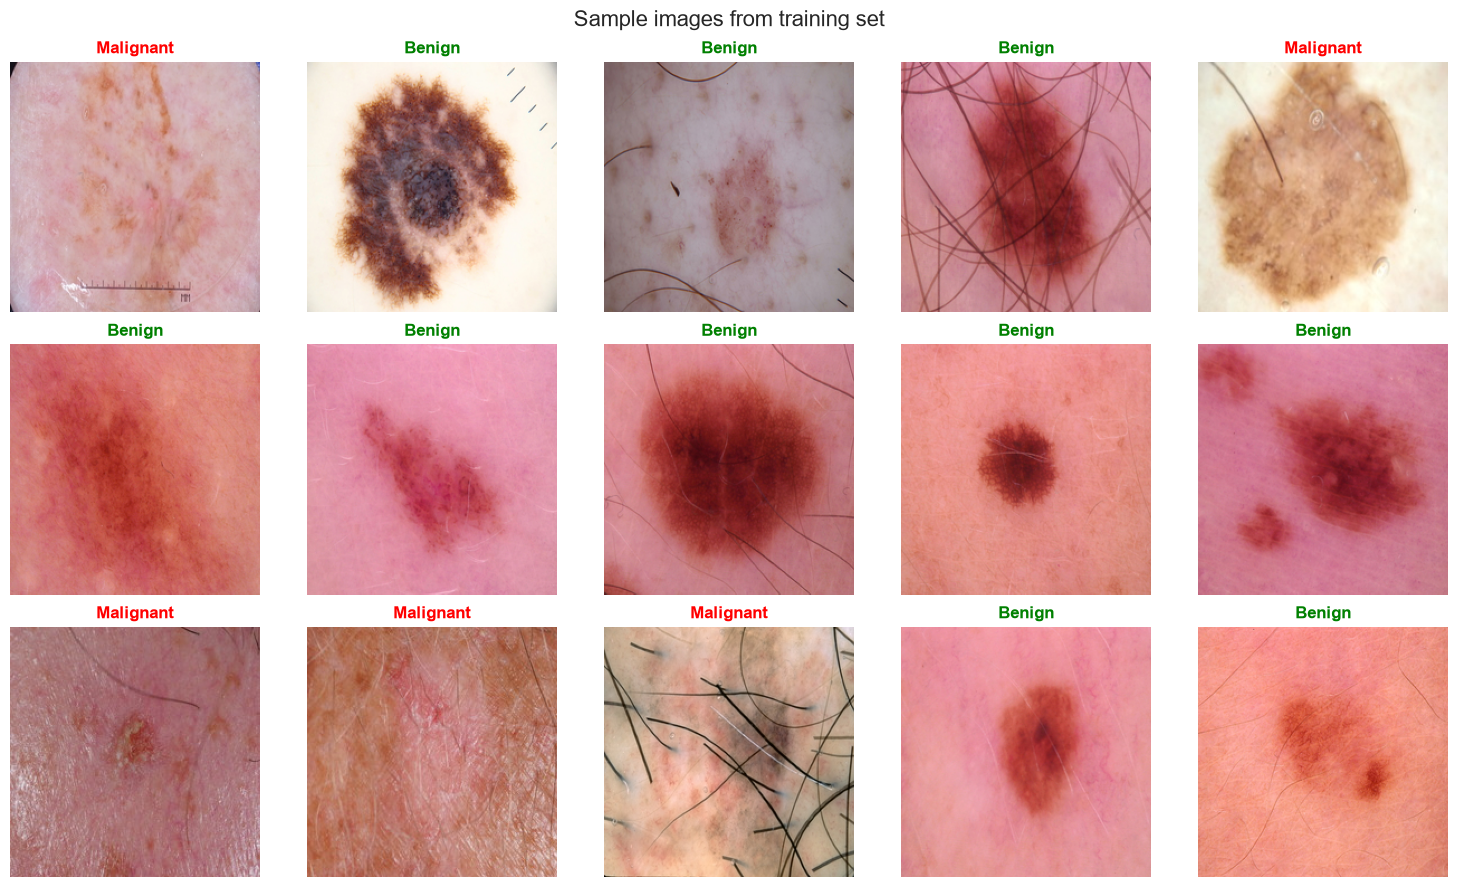

In [4]:
rng = np.random.RandomState(SEED)
idx = rng.choice(len(all_train_paths), 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample images from training set', fontsize=16)
for ax, i in zip(axes.flat, idx):
    ax.imshow(Image.open(all_train_paths[i]).convert('RGB'))
    lab = all_train_labels[i]
    ax.set_title(CLASS_NAMES[lab].capitalize(), color='red' if lab else 'green', fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.show()

## 2.3 Class distribution

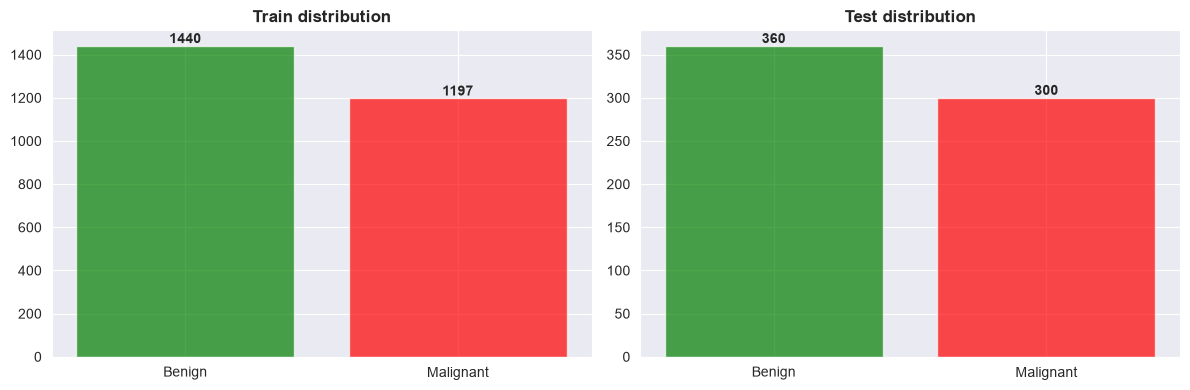

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, y) in zip(axes, [('Train', all_train_labels), ('Test', test_labels)]):
    counts = np.bincount(y)
    ax.bar(['Benign', 'Malignant'], counts, color=['green', 'red'], alpha=0.7)
    for i, c in enumerate(counts):
        ax.text(i, c, str(c), ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'{title} distribution', fontweight='bold')
plt.tight_layout(); plt.show()

## 2.4 Image properties (size, mode, file size)

Unique image sizes : {(224, 224): 2637}
Color modes        : {'RGB': 2637}

File size (KB) by class:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
benign,1440.0,54.2,7.2,21.3,50.6,54.0,58.4,81.9
malignant,1197.0,46.6,20.0,4.1,34.4,48.4,60.9,103.0


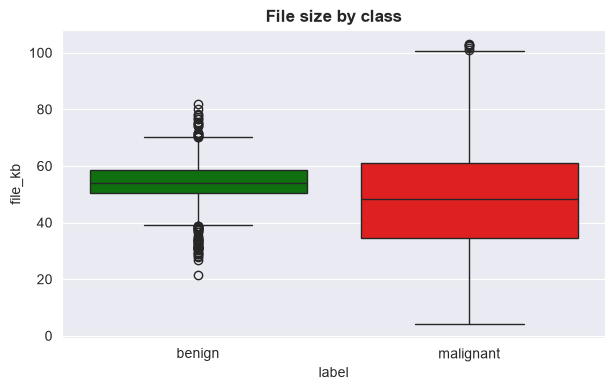

In [6]:
rows = []
for p, y in zip(all_train_paths, all_train_labels):
    with Image.open(p) as im:
        rows.append({'width': im.size[0], 'height': im.size[1], 'mode': im.mode,
                     'file_kb': os.path.getsize(p) / 1024, 'label': CLASS_NAMES[y]})
meta_df = pd.DataFrame(rows)

print('Unique image sizes :', meta_df.groupby(['width', 'height']).size().to_dict())
print('Color modes        :', meta_df['mode'].value_counts().to_dict())
print('\nFile size (KB) by class:')
display(meta_df.groupby('label')['file_kb'].describe().round(1))

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=meta_df, x='label', y='file_kb', palette={'benign': 'green', 'malignant': 'red'}, ax=ax)
ax.set_title('File size by class', fontweight='bold'); plt.show()

## 2.5 Duplicate / data-leakage check
Agar same image train aur test dono me ho to accuracy jhooti (inflated) aati hai. Yahan exact duplicates check hote hain.

In [7]:
import hashlib

def md5_file(p):
    with open(p, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

train_hash = pd.Series([md5_file(p) for p in all_train_paths])
test_hash  = pd.Series([md5_file(p) for p in test_paths])

dup_in_train = int(train_hash.duplicated().sum())
dup_in_test  = int(test_hash.duplicated().sum())
overlap      = set(train_hash) & set(test_hash)

# Same image, lekin different label (label noise)
tmp = pd.DataFrame({'h': train_hash, 'y': all_train_labels})
conflict = int((tmp.groupby('h')['y'].nunique() > 1).sum())

print(f'Duplicates inside train        : {dup_in_train}')
print(f'Duplicates inside test         : {dup_in_test}')
print(f'Train-Test overlap (LEAKAGE)   : {len(overlap)}')
print(f'Same image with conflicting label : {conflict}')
if len(overlap) == 0 and conflict == 0:
    print('\nOK: koi leakage ya label conflict nahi mila')
else:
    print('\nWARNING: duplicates mile - neeche cell se test se hata sakte ho')

Duplicates inside train        : 1
Duplicates inside test         : 0
Train-Test overlap (LEAKAGE)   : 0
Same image with conflicting label : 0

OK: koi leakage ya label conflict nahi mila


In [8]:
# Optional: agar train-test overlap mila to test se duplicates hata do
if len(overlap) > 0:
    keep = ~test_hash.isin(overlap).values
    test_paths, test_labels = test_paths[keep], test_labels[keep]
    print('Test samples after removing leakage:', len(test_paths))
else:
    print('Kuch hatane ki zaroorat nahi')

Kuch hatane ki zaroorat nahi


## 2.6 Per-image features (brightness, contrast, color, sharpness)
Har class ke random 500 images se features nikal kar compare karte hain. `dark_ratio` lesion ke size ka rough andaza hai (dark pixels ka fraction).

In [9]:
N_EDA = 500
rng = np.random.RandomState(SEED)

def img_features(path):
    im = Image.open(path).convert('RGB').resize(IMG_SIZE)
    a = np.asarray(im, dtype='float32')
    g = a.mean(axis=2)
    lap = -4 * g + np.roll(g, 1, 0) + np.roll(g, -1, 0) + np.roll(g, 1, 1) + np.roll(g, -1, 1)
    hsv = np.asarray(im.convert('HSV'), dtype='float32')
    return {'R': a[..., 0].mean(), 'G': a[..., 1].mean(), 'B': a[..., 2].mean(),
            'brightness': g.mean(), 'contrast': g.std(), 'sharpness': lap.var(),
            'saturation': hsv[..., 1].mean(), 'hue': hsv[..., 0].mean(),
            'dark_ratio': (g < 80).mean()}

feat_rows = []
for c, cls in enumerate(CLASS_NAMES):
    pool = all_train_paths[all_train_labels == c]
    for p in rng.choice(pool, min(N_EDA, len(pool)), replace=False):
        feat_rows.append({**img_features(p), 'label': cls})
feat_df = pd.DataFrame(feat_rows)

display(feat_df.groupby('label').mean().round(2).T)

label,benign,malignant
R,204.369995,178.500000
G,136.220001,137.169998
B,140.470001,132.449997
brightness,160.350006,149.369995
contrast,27.190001,31.809999
sharpness,145.520004,264.420013
saturation,90.669998,76.870003
hue,147.380005,90.589996
dark_ratio,0.040000,0.070000


## 2.7 Feature distributions by class + statistical test

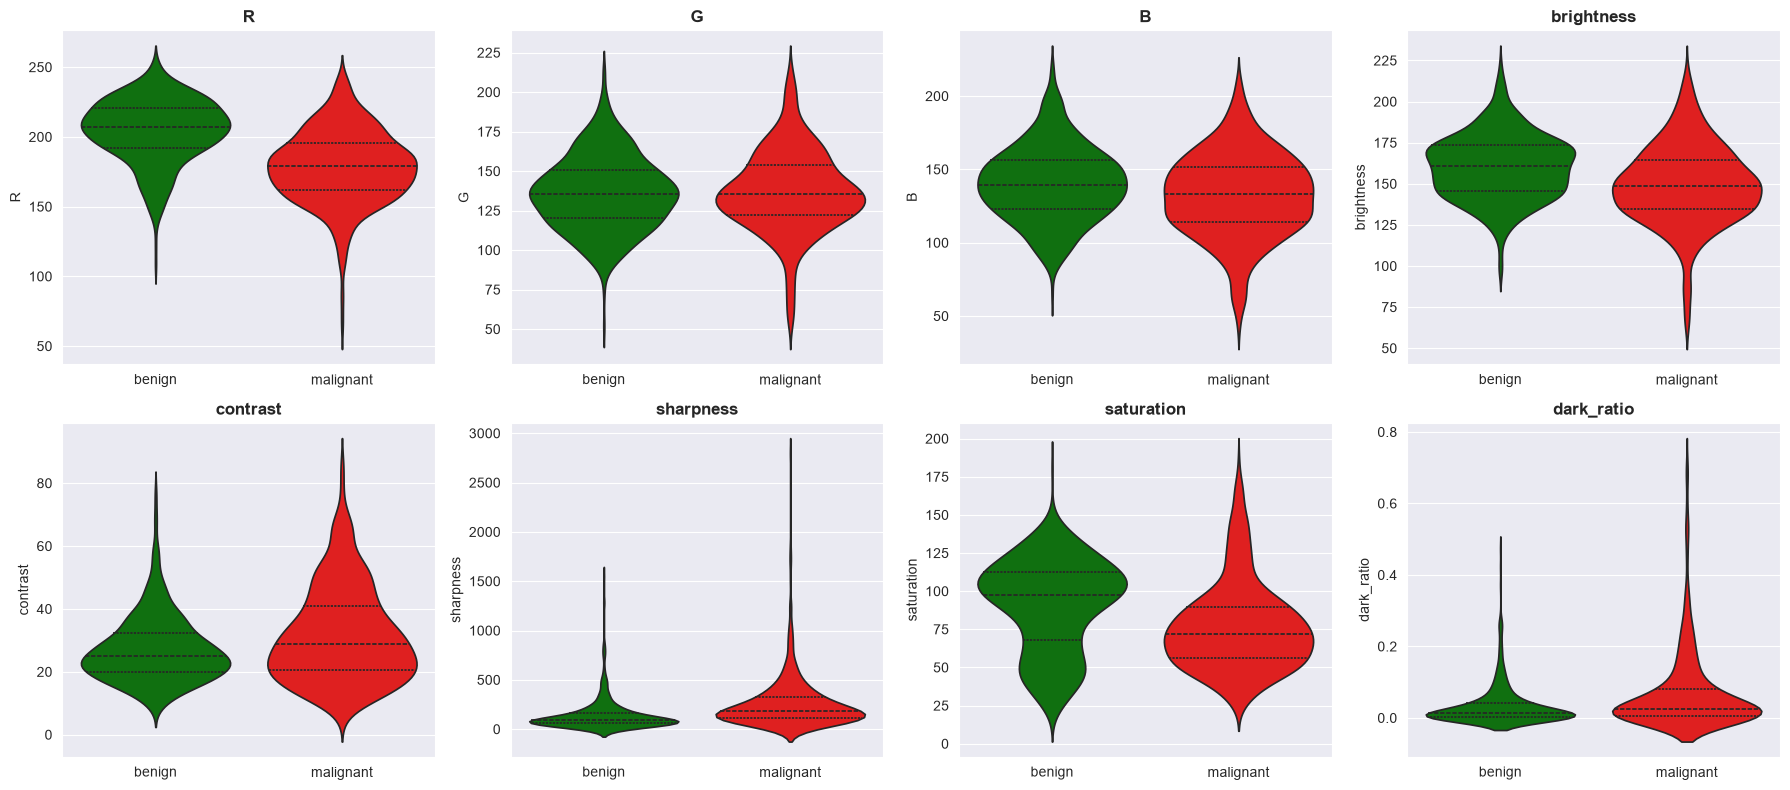

,feature,benign_mean,malignant_mean,p_value,significant (p<0.05)
0,R,204.3660,178.4959,0.000,True
1,G,136.2244,137.1697,0.467,False
2,B,140.4740,132.4529,0.000,True
3,brightness,160.3548,149.3728,0.000,True
4,contrast,27.1924,31.8141,0.000,True
5,sharpness,145.5168,264.4220,0.000,True
6,saturation,90.6658,76.8682,0.000,True
7,dark_ratio,0.0354,0.0730,0.000,True
8,hue,147.3827,90.5900,0.000,True


In [10]:
from scipy.stats import mannwhitneyu

feats = ['R', 'G', 'B', 'brightness', 'contrast', 'sharpness', 'saturation', 'dark_ratio']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, f in zip(axes.flat, feats):
    sns.violinplot(data=feat_df, x='label', y=f, palette={'benign': 'green', 'malignant': 'red'}, ax=ax, inner='quartile')
    ax.set_title(f, fontweight='bold'); ax.set_xlabel('')
plt.tight_layout(); plt.show()

# Kya difference statistically significant hai? (Mann-Whitney U)
stat_rows = []
for f in feats + ['hue']:
    a = feat_df.loc[feat_df.label == 'benign', f]; b = feat_df.loc[feat_df.label == 'malignant', f]
    p = mannwhitneyu(a, b).pvalue
    stat_rows.append({'feature': f, 'benign_mean': a.mean(), 'malignant_mean': b.mean(),
                      'p_value': p, 'significant (p<0.05)': p < 0.05})
display(pd.DataFrame(stat_rows).round(4))

## 2.8 RGB intensity histograms + mean image per class (RAM-safe: images ek ek karke process hoti hain)

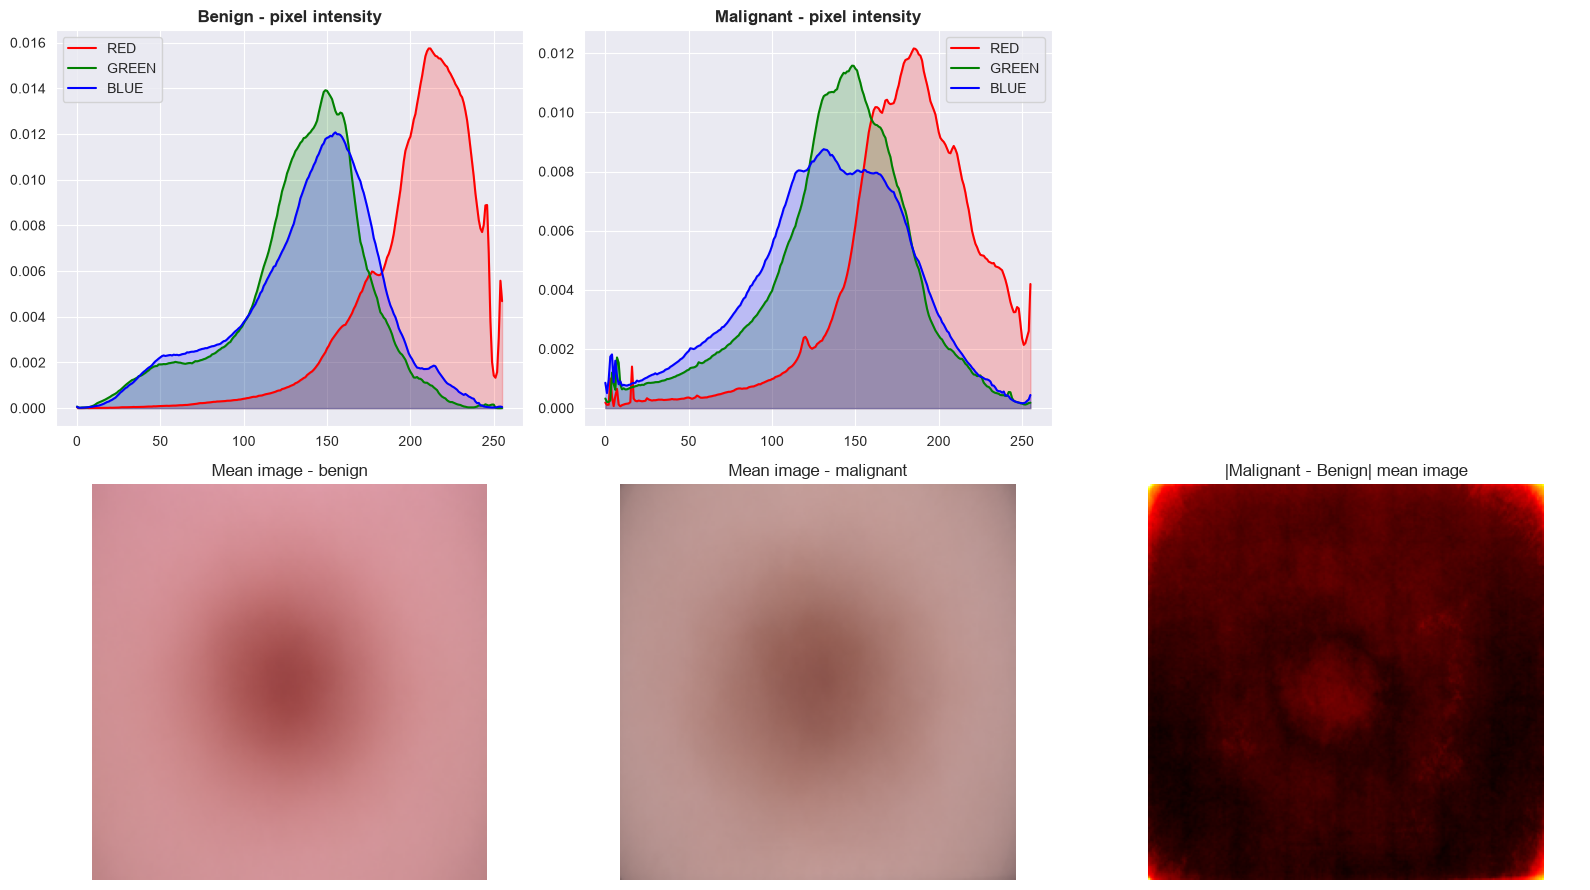

In [11]:
def load_u8(p):
    return np.asarray(Image.open(p).convert('RGB').resize(IMG_SIZE))      # uint8, 150 KB per image

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
mean_imgs = {}
for c, cls in enumerate(CLASS_NAMES):
    pool = all_train_paths[all_train_labels == c]
    sel = np.random.RandomState(SEED).choice(pool, min(300, len(pool)), replace=False)

    sum_img = np.zeros((*IMG_SIZE, 3), dtype=np.float64)    # running sum (sirf 1 image jitni memory)
    hist = np.zeros((3, 256), dtype=np.int64)               # running histogram
    for p in sel:
        a = load_u8(p)
        sum_img += a
        for ch in range(3):
            hist[ch] += np.bincount(a[..., ch].ravel(), minlength=256)
    mean_imgs[cls] = sum_img / len(sel)

    for ch, col in enumerate(['red', 'green', 'blue']):
        density = hist[ch] / hist[ch].sum()
        axes[0, c].plot(np.arange(256), density, color=col, label=col.upper())
        axes[0, c].fill_between(np.arange(256), density, color=col, alpha=0.2)
    axes[0, c].set_title(f'{cls.capitalize()} - pixel intensity', fontweight='bold'); axes[0, c].legend()
    axes[1, c].imshow(mean_imgs[cls].astype('uint8')); axes[1, c].set_title(f'Mean image - {cls}'); axes[1, c].axis('off')

diff = np.abs(mean_imgs['malignant'] - mean_imgs['benign']).mean(axis=2)
axes[0, 2].axis('off')
axes[1, 2].imshow(diff, cmap='hot'); axes[1, 2].set_title('|Malignant - Benign| mean image'); axes[1, 2].axis('off')
plt.tight_layout(); plt.show()

## 2.9 Feature correlation

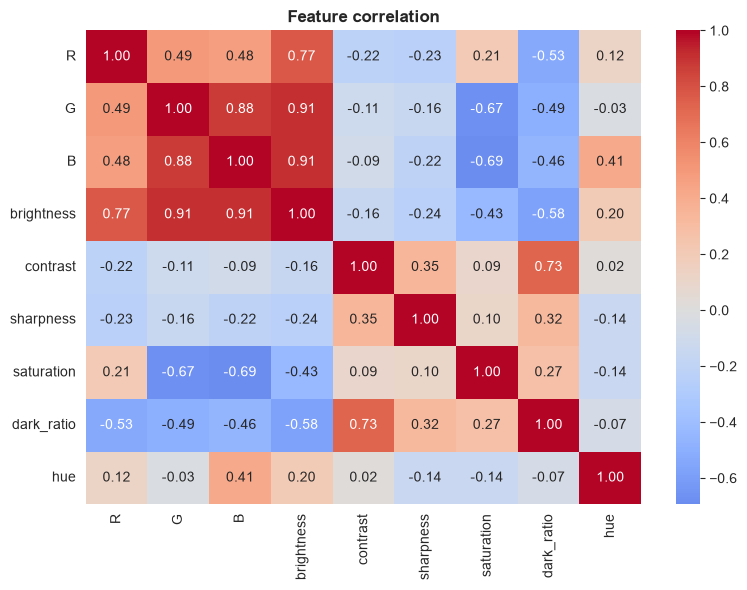

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(feat_df[feats + ['hue']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation', fontweight='bold'); plt.tight_layout(); plt.show()

## 2.10 PCA: kya classes raw pixels se alag hoti hain?
Agar PCA me classes bohat overlap karti hain to problem mushkil hai aur deep learning ki zaroorat hai.

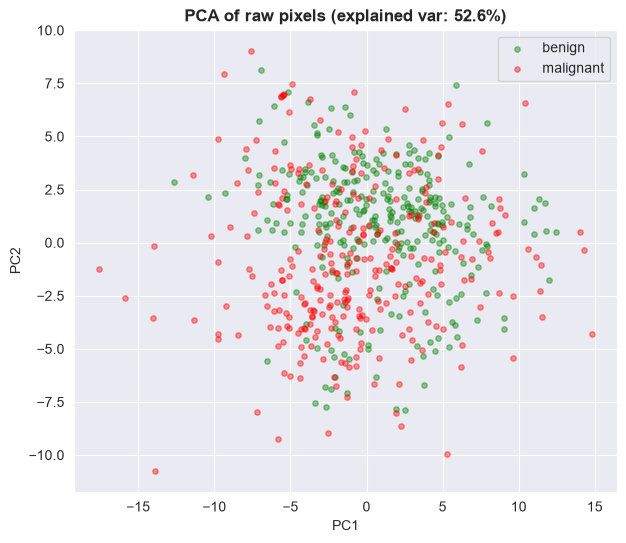

In [13]:
from sklearn.decomposition import PCA

Xs, ys = [], []
for c in range(2):
    pool = all_train_paths[all_train_labels == c]
    for p in np.random.RandomState(SEED).choice(pool, min(300, len(pool)), replace=False):
        Xs.append(np.asarray(Image.open(p).convert('RGB').resize((32, 32)), dtype='float32').ravel() / 255.)
        ys.append(c)
Xs, ys = np.array(Xs), np.array(ys)

pca = PCA(n_components=2, random_state=SEED).fit(Xs)
Z = pca.transform(Xs)
plt.figure(figsize=(7, 6))
for c, col in enumerate(['green', 'red']):
    plt.scatter(Z[ys == c, 0], Z[ys == c, 1], c=col, alpha=0.4, s=15, label=CLASS_NAMES[c])
plt.title(f'PCA of raw pixels (explained var: {pca.explained_variance_ratio_.sum():.1%})', fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.show()

## 2.11 Benign vs Malignant side-by-side

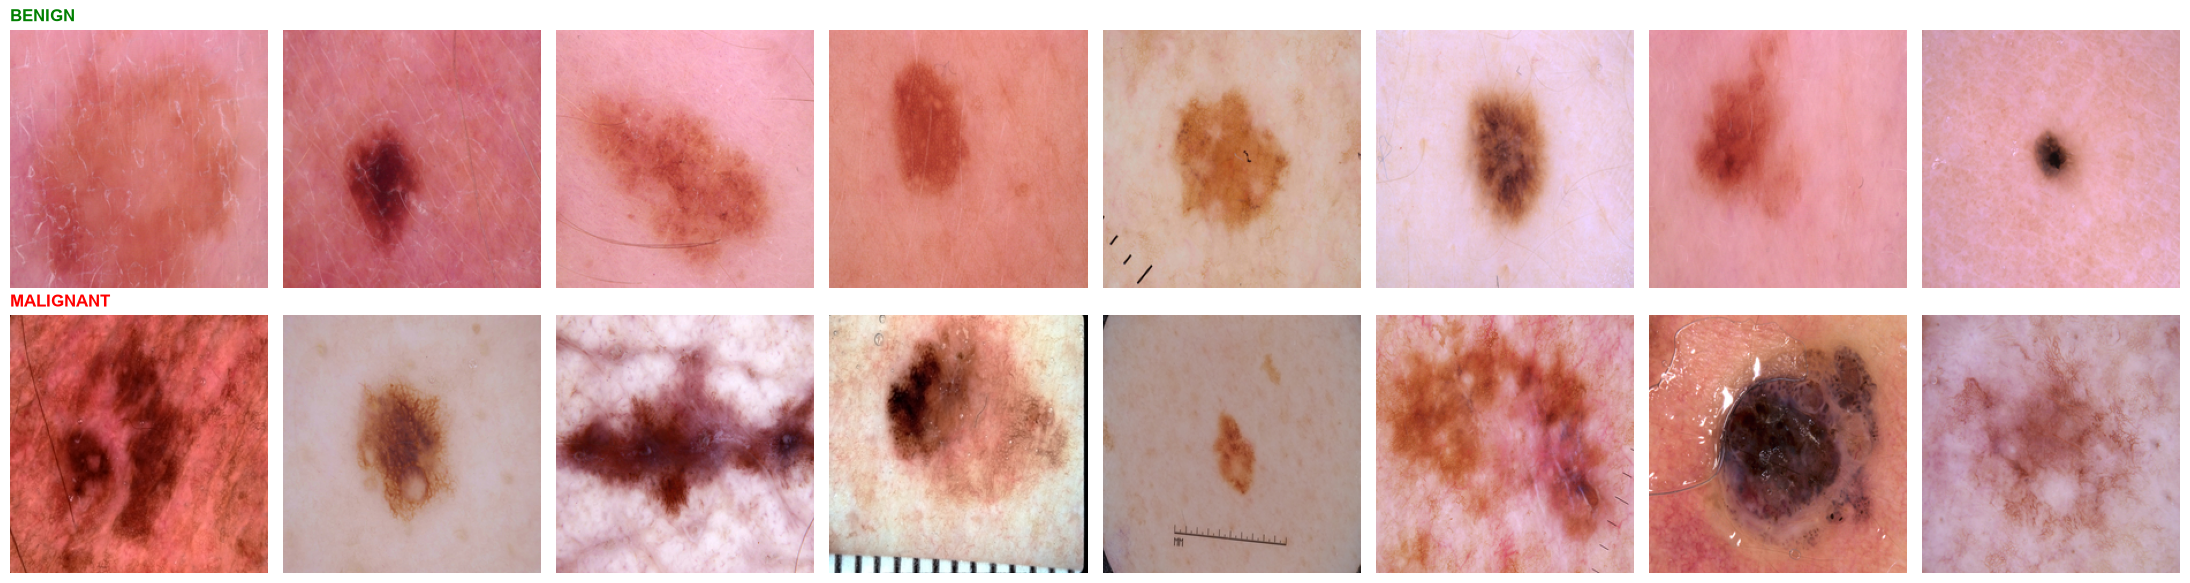

In [14]:
fig, axes = plt.subplots(2, 8, figsize=(22, 6))
for r, c in enumerate(range(2)):
    pool = all_train_paths[all_train_labels == c]
    for ax, p in zip(axes[r], np.random.RandomState(7).choice(pool, 8, replace=False)):
        ax.imshow(Image.open(p).convert('RGB')); ax.axis('off')
    axes[r, 0].set_title(CLASS_NAMES[c].upper(), color='green' if c == 0 else 'red', fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

## 2.12 EDA Key Takeaways
- Image size/mode: sab images same size aur RGB hain, to extra resizing ka masla nahi.
- Duplicate check: leakage nahi hona chahiye (upar result dekho).
- Class balance mostly theek hai, phir bhi class weights use kiye hain.
- Brightness / color / dark_ratio jaisi features me kuch statistical difference ho sakta hai, magar PCA me classes overlap karti hain, yaani sirf simple pixel stats se classify nahi hoga. Isi liye deep learning (CNN / transfer learning) chahiye.
- Lesion ke andar texture aur border irregularity important hai, isi liye Grad-CAM se baad me check karenge.

# 3. Data Pipeline

## 3.1 Stratified Train / Validation split + class weights

In [15]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths, all_train_labels,
    test_size=VAL_SPLIT, random_state=SEED, stratify=all_train_labels)

cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_labels)
class_weight = {0: float(cw[0]), 1: float(cw[1])}

print(f'Train : {len(train_paths)}')
print(f'Val   : {len(val_paths)}')
print(f'Test  : {len(test_paths)}')
print('Class weights:', class_weight)

Train : 2109
Val   : 528
Test  : 660
Class weights: {0: 0.9153645833333334, 1: 1.1018808777429467}


## 3.2 `tf.data` datasets
Images 0-255 float me aati hain. Har model apna preprocessing **model ke andar** karta hai, is liye train/val/test me koi mismatch nahi hota.

In [16]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.ensure_shape(img, (IMG_SIZE[0], IMG_SIZE[1], 3))
    return tf.cast(img, tf.float32), tf.reshape(tf.cast(label, tf.float32), [1])

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training and not CACHE_IN_RAM:
        # shuffle sirf file-paths ka (bohat halka), decode uske baad
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if CACHE_IN_RAM:
        ds = ds.cache()
        if training:
            ds = ds.shuffle(500, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH).prefetch(2)

train_ds = make_ds(train_paths, train_labels, training=True)
val_ds   = make_ds(val_paths,   val_labels)
test_ds  = make_ds(test_paths,  test_labels)

xb, yb = next(iter(train_ds))
print('Batch:', xb.shape, yb.shape, '| pixel range:', float(tf.reduce_min(xb)), '-', float(tf.reduce_max(xb)))

Batch: (16, 224, 224, 3) (16, 1) | pixel range: 0.0 - 255.0


## 3.3 Data augmentation layers (sirf training me active)

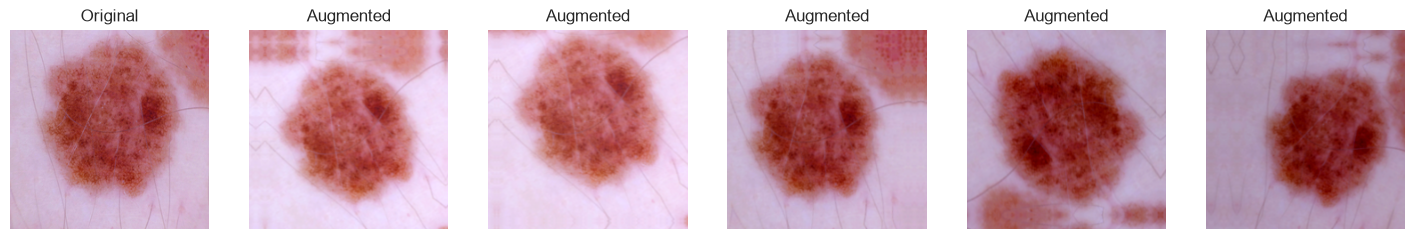

In [17]:
def get_augmentation():
    return keras.Sequential([
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.15),
        layers.RandomBrightness(0.15, value_range=(0, 255)),
    ], name='augmentation')

# Preview
aug = get_augmentation()
sample = xb[0:1]
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(sample[0].numpy().astype('uint8')); axes[0].set_title('Original')
for ax in axes[1:]:
    ax.imshow(aug(sample, training=True)[0].numpy().clip(0, 255).astype('uint8')); ax.set_title('Augmented')
for ax in axes: ax.axis('off')
plt.show()

# 4. Helper Functions

## 4.1 Metrics, plots, threshold tuning, TTA

In [18]:
def compute_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'Accuracy'    : accuracy_score(y_true, y_pred),
        'Balanced_Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision'   : precision_score(y_true, y_pred, zero_division=0),
        'Recall'      : recall_score(y_true, y_pred, zero_division=0),   # sensitivity (malignant pakadna)
        'Specificity' : tn / (tn + fp + 1e-9),
        'F1'          : f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC'     : roc_auc_score(y_true, y_prob),
        'PR_AUC'      : average_precision_score(y_true, y_prob),
        'MCC'         : matthews_corrcoef(y_true, y_pred),
        'Threshold'   : thr,
        'FN (missed cancer)': int(fn), 'FP': int(fp),
    }

def plot_cm(y_true, y_pred, title, ax=None, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax,
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

def plot_history(h, title, split_at=None):
    keys = [('accuracy', 'Accuracy'), ('loss', 'Loss'), ('auc', 'AUC'), ('recall', 'Recall')]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, (k, t) in zip(axes, keys):
        ax.plot(h[k], label='train', lw=2)
        ax.plot(h['val_' + k], label='val', lw=2)
        if split_at:
            ax.axvline(split_at - 0.5, color='gray', ls='--', label='fine-tune start')
        ax.set_title(f'{title} - {t}', fontweight='bold'); ax.set_xlabel('Epoch'); ax.legend()
    plt.tight_layout(); plt.show()

def tune_threshold(y_true, y_prob, mode='f1', min_recall=0.95):
    # Threshold sirf VALIDATION set par choose hota hai (test par kabhi nahi)
    best_thr, best_score = 0.5, -1
    for thr in np.linspace(0.05, 0.95, 91):
        pred = (y_prob >= thr).astype(int)
        rec = recall_score(y_true, pred, zero_division=0)
        if mode == 'f1':
            score = f1_score(y_true, pred, zero_division=0)
        else:  # 'recall': min_recall pura karo, phir specificity max karo
            tn, fp, _, _ = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
            score = (tn / (tn + fp + 1e-9)) if rec >= min_recall else -1
        if score > best_score:
            best_thr, best_score = thr, score
    return float(best_thr)

def _apply(ds, f):
    return ds.map(lambda x, y: (f(x), y), num_parallel_calls=AUTOTUNE)

TTA_FUNCS = [lambda x: x,
             tf.image.flip_left_right,
             tf.image.flip_up_down,
             lambda x: tf.image.flip_up_down(tf.image.flip_left_right(x))]

def predict_tta(model, ds):
    preds = [model.predict(_apply(ds, f), verbose=0).ravel() for f in TTA_FUNCS]
    return np.mean(preds, axis=0)

def evaluate_and_store(name, model, tta=False, show=True):
    key = f'{name} + TTA' if tta else name
    if tta:
        vp, tp = predict_tta(model, val_ds), predict_tta(model, test_ds)
    else:
        vp = model.predict(val_ds, verbose=0).ravel()
        tp = model.predict(test_ds, verbose=0).ravel()
    val_probs[key], test_probs[key] = vp, tp
    m = compute_metrics(test_labels, tp, 0.5)
    results[key] = m
    if show:
        print('=' * 60); print(f'{key} - TEST RESULTS (threshold 0.5)'); print('=' * 60)
        print(pd.Series(m).round(4).to_string())
        print('\n', classification_report(test_labels, (tp >= 0.5).astype(int),
                                          target_names=['Benign', 'Malignant'], digits=4))
        plot_cm(test_labels, (tp >= 0.5).astype(int), f'{key} - Confusion Matrix')
        plt.show()
    return m

print('Helpers ready')

Helpers ready


# 5. Model Builders

## 5.1 Custom CNN + Transfer learning builders

In [19]:
def get_backbone(model):
    return [l for l in model.layers if isinstance(l, keras.Model) and l.name != 'augmentation'][0]

# ---------------- Custom CNN (baseline) ----------------
def build_custom_cnn():
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = get_augmentation()(inputs)
    x = layers.Rescaling(1. / 255)(x)
    for f, d in [(32, 0.20), (64, 0.25), (128, 0.30), (256, 0.35)]:
        x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
        x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
        x = layers.MaxPool2D()(x)
        x = layers.Dropout(d)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='Custom_CNN')

# ---------------- Transfer learning ----------------
# Har backbone ka apna sahi preprocessing (input hamesha 0-255)
BACKBONES = {
    'resnet50v2'     : (keras.applications.ResNet50V2,
                        lambda: [layers.Rescaling(1. / 127.5, offset=-1)]),
    'efficientnetv2s': (keras.applications.EfficientNetV2S,
                        lambda: []),   # preprocessing model ke andar built-in hai
    'densenet121'    : (keras.applications.DenseNet121,
                        lambda: [layers.Rescaling(1. / 255),
                                 layers.Normalization(mean=[0.485, 0.456, 0.406],
                                                      variance=[0.229 ** 2, 0.224 ** 2, 0.225 ** 2])]),
}

def build_transfer(backbone='efficientnetv2s', units=256, dropout=0.4, name=None):
    fn, prep_layers = BACKBONES[backbone]
    base = fn(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
    base.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = get_augmentation()(inputs)
    for l in prep_layers():
        x = l(x)
    x = base(x, training=False)          # BatchNorm stats frozen rahen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name=name or backbone)

print('Builders ready:', list(BACKBONES))

Builders ready: ['resnet50v2', 'efficientnetv2s', 'densenet121']


## 5.2 Compile / callbacks / two-stage training helper

In [20]:
def get_metrics():
    return [keras.metrics.BinaryAccuracy(name='accuracy'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')]

def compile_model(model, lr, label_smoothing=0.0):
    model.compile(optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
                  loss=keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing),
                  metrics=get_metrics())

def get_callbacks(tag, patience=8):
    return [
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_auc', mode='max', patience=patience, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'best_{tag}.weights.h5', monitor='val_auc', mode='max',
                        save_best_only=True, save_weights_only=True, verbose=0),
    ]

def train_two_stage(model, tag, epochs_head=EPOCHS_HEAD, epochs_ft=EPOCHS_FT,
                    unfreeze=UNFREEZE, lr_head=LR_HEAD, lr_ft=LR_FT, label_smoothing=0.0):
    # ---- Stage 1: backbone frozen, sirf head train ----
    print('\n>>> STAGE 1: training head (backbone frozen)')
    compile_model(model, lr_head, label_smoothing)
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=epochs_head,
                   class_weight=class_weight, callbacks=get_callbacks(tag + '_head', patience=5))

    # ---- Stage 2: last N layers unfreeze (BatchNorm frozen) ----
    print('\n>>> STAGE 2: fine-tuning last', unfreeze, 'layers')
    base = get_backbone(model)
    base.trainable = True
    for l in base.layers[:-unfreeze]:
        l.trainable = False
    for l in base.layers:
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False
    compile_model(model, lr_ft, label_smoothing)      # recompile zaroori hai
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=epochs_ft,
                   class_weight=class_weight, callbacks=get_callbacks(tag + '_ft', patience=8))

    merged = {k: h1.history[k] + h2.history[k] for k in h1.history if k in h2.history}
    return merged, len(h1.history['loss'])

print('Training helpers ready')

Training helpers ready


# 6. Model 1: Custom CNN (baseline)

## 6.1 Build

In [22]:
cnn_model = build_custom_cnn()
cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 224, 224, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 224, 224, 32)        │           9,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 112, 112, 64)        │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 112, 112, 64)        │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,208,673 (4.61 MB)

 Trainable params: 1,206,497 (4.60 MB)

 Non-trainable params: 2,176 (8.50 KB)

## 6.2 Train

In [ ]:
compile_model(cnn_model, lr=1e-3)
h = cnn_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_CNN,
                  class_weight=class_weight, callbacks=get_callbacks('cnn', patience=10))
histories['Custom CNN'] = (h.history, None)

Epoch 1/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 820s 6s/step - accuracy: 0.7079 - auc: 0.7822 - loss: 0.6056 - precision: 0.6598 - recall: 0.7356 - val_accuracy: 0.5455 - val_auc: 0.8409 - val_loss: 0.9872 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 833s 6s/step - accuracy: 0.7354 - auc: 0.8119 - loss: 0.5388 - precision: 0.6805 - recall: 0.7858 - val_accuracy: 0.7614 - val_auc: 0.8766 - val_loss: 0.4747 - val_precision: 0.8032 - val_recall: 0.6292 - learning_rate: 0.0010
Epoch 3/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 835s 6s/step - accuracy: 0.7596 - auc: 0.8256 - loss: 0.5189 - precision: 0.7091 - recall: 0.7973 - val_accuracy: 0.5644 - val_auc: 0.8393 - val_loss: 1.3002 - val_precision: 0.9167 - val_recall: 0.0458 - learning_rate: 0.0010
Epoch 4/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 751s 6s/step - accuracy: 0.7620 - auc: 0.8397 - loss: 0.4961 - precision: 0.7015 - recall: 0.8276 - val_accuracy: 0.5019 - val_auc: 0.8223 - val_loss: 

## 6.3 Training curves

In [ ]:
plot_history(histories['Custom CNN'][0], 'Custom CNN')

## 6.4 Test evaluation

In [ ]:
evaluate_and_store('Custom CNN', cnn_model)

# 7. Model 2: ResNet50V2 (Transfer Learning + Fine-tuning)
Original me ResNet50 sirf frozen tha. Ab 2-stage training hai: pehle head, phir last 50 layers fine-tune.

## 7.1 Build

In [ ]:
resnet_model = build_transfer('resnet50v2', units=256, dropout=0.4, name='ResNet50V2')
resnet_model.summary()

## 7.2 Train (2 stages)

In [ ]:
hist, split = train_two_stage(resnet_model, 'resnet50v2')
histories['ResNet50V2'] = (hist, split)

## 7.3 Training curves

In [ ]:
plot_history(histories['ResNet50V2'][0], 'ResNet50V2', split_at=histories['ResNet50V2'][1])

## 7.4 Test evaluation

In [ ]:
evaluate_and_store('ResNet50V2', resnet_model)

# 8. Model 3: EfficientNetV2-S (naya, behtar algorithm)
EfficientNetV2 image classification me ResNet se zyada accurate aur efficient hai. Medical images me bhi aksar best results deta hai.

Pehle **hyperparameter tuning**, phir best settings se 2-stage training.

## 8.1 Hyperparameter tuning (Keras Tuner - Random Search)

In [ ]:
def build_for_tuner(hp):
    model = build_transfer('efficientnetv2s',
                           units=hp.Choice('units', [128, 256, 512]),
                           dropout=hp.Float('dropout', 0.2, 0.6, step=0.1))
    compile_model(model,
                  lr=hp.Choice('lr', [3e-4, 1e-3, 3e-3]),
                  label_smoothing=hp.Choice('label_smoothing', [0.0, 0.05, 0.1]))
    return model

tuner = kt.RandomSearch(
    build_for_tuner,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=8,                 # zyada time ho to 15-20 kar do
    directory='kt_logs', project_name='effnetv2s_head',
    overwrite=True, seed=SEED)

tuner.search(train_ds, validation_data=val_ds, epochs=8, class_weight=class_weight,
             callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=3)])

## 8.2 Best hyperparameters

In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]
print('Best hyperparameters:')
for k in ['units', 'dropout', 'lr', 'label_smoothing']:
    print(f'  {k:16s}: {best_hp.get(k)}')

trials = [{**t.hyperparameters.values, 'val_auc': t.score} for t in tuner.oracle.get_best_trials(8)]
display(pd.DataFrame(trials))

## 8.3 Build with best hyperparameters

In [ ]:
eff_model = build_transfer('efficientnetv2s',
                           units=best_hp.get('units'),
                           dropout=best_hp.get('dropout'),
                           name='EfficientNetV2S')

## 8.4 Train (2 stages)

In [ ]:
hist, split = train_two_stage(eff_model, 'effnetv2s',
                              lr_head=best_hp.get('lr'),
                              label_smoothing=best_hp.get('label_smoothing'))
histories['EfficientNetV2S'] = (hist, split)

## 8.5 Training curves

In [ ]:
plot_history(histories['EfficientNetV2S'][0], 'EfficientNetV2S', split_at=histories['EfficientNetV2S'][1])

## 8.6 Test evaluation

In [ ]:
evaluate_and_store('EfficientNetV2S', eff_model)

# 9. Model 4: DenseNet121
DenseNet121 skin-lesion / chest X-ray jaise medical tasks me popular hai. Ensemble ke liye ek diverse model.

## 9.1 Build

In [ ]:
dense_model = build_transfer('densenet121', units=256, dropout=0.4, name='DenseNet121')

## 9.2 Train (2 stages)

In [ ]:
hist, split = train_two_stage(dense_model, 'densenet121', unfreeze=60)
histories['DenseNet121'] = (hist, split)

## 9.3 Training curves

In [ ]:
plot_history(histories['DenseNet121'][0], 'DenseNet121', split_at=histories['DenseNet121'][1])

## 9.4 Test evaluation

In [ ]:
evaluate_and_store('DenseNet121', dense_model)

# 10. Test-Time Augmentation (TTA)
Har image ke 4 versions (original, left-right flip, up-down flip, dono) par predict karke average. Isse predictions zyada stable hoti hain.

In [ ]:
tta_models = {'ResNet50V2': resnet_model, 'EfficientNetV2S': eff_model, 'DenseNet121': dense_model}
for name, m in tta_models.items():
    evaluate_and_store(name, m, tta=True, show=False)

display(pd.DataFrame({k: results[k] for k in results if 'TTA' in k or k in tta_models}).T
        [['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].round(4))

# 11. Ensemble
Teeno transfer-learning models (TTA ke saath) ki probabilities ka average. Ensemble aksar kisi bhi single model se behtar hota hai.

In [ ]:
members = ['ResNet50V2 + TTA', 'EfficientNetV2S + TTA', 'DenseNet121 + TTA']
ENS = 'Ensemble (3 models + TTA)'

val_probs[ENS]  = np.mean([val_probs[k]  for k in members], axis=0)
test_probs[ENS] = np.mean([test_probs[k] for k in members], axis=0)
results[ENS]    = compute_metrics(test_labels, test_probs[ENS], 0.5)

print(pd.Series(results[ENS]).round(4).to_string())
print('\n', classification_report(test_labels, (test_probs[ENS] >= 0.5).astype(int),
                                  target_names=['Benign', 'Malignant'], digits=4))
plot_cm(test_labels, (test_probs[ENS] >= 0.5).astype(int), ENS, cmap='Purples'); plt.show()

# 12. Threshold Tuning
Default threshold 0.5 hota hai, lekin cancer detection me **malignant miss karna (False Negative)** sabse bura hai.
Threshold **validation set** par choose hota hai (test leak nahi hota), phir test par apply.

- `f1` mode: best F1
- `recall` mode: kam az kam 95% recall, aur us ke saath best specificity

In [ ]:
rows = {}
for mode in ['f1', 'recall']:
    thr = tune_threshold(val_labels, val_probs[ENS], mode=mode, min_recall=0.95)
    rows[f'thr={thr:.2f} (mode: {mode})'] = compute_metrics(test_labels, test_probs[ENS], thr)
    results[f'{ENS} | thr-{mode}'] = rows[f'thr={thr:.2f} (mode: {mode})']
rows['thr=0.50 (default)'] = results[ENS]

display(pd.DataFrame(rows).T[['Threshold', 'Accuracy', 'Precision', 'Recall', 'Specificity',
                              'F1', 'FN (missed cancer)', 'FP']].round(4))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, m) in zip(axes, rows.items()):
    pred = (test_probs[ENS] >= m['Threshold']).astype(int)
    plot_cm(test_labels, pred, title, ax=ax, cmap='Purples')
plt.tight_layout(); plt.show()

# 13. Final Model Comparison

## 13.1 Metrics table (F1 ke hisaab se sorted)

In [ ]:
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
display(results_df[['Accuracy', 'Balanced_Acc', 'Precision', 'Recall', 'Specificity',
                    'F1', 'ROC_AUC', 'PR_AUC', 'MCC', 'Threshold', 'FN (missed cancer)']].round(4))
results_df.to_csv('model_comparison.csv')
print('Saved: model_comparison.csv')

## 13.2 Bar chart

In [ ]:
plot_models = ['Custom CNN', 'ResNet50V2', 'EfficientNetV2S', 'DenseNet121', ENS]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x = np.arange(len(metrics)); w = 0.16

plt.figure(figsize=(13, 6))
for i, name in enumerate(plot_models):
    plt.bar(x + (i - 2) * w, [results[name][m] for m in metrics], w, label=name)
plt.xticks(x, metrics); plt.ylim(0.5, 1.0); plt.ylabel('Score')
plt.title('Model comparison on test set', fontweight='bold'); plt.legend(); plt.tight_layout(); plt.show()

## 13.3 ROC and Precision-Recall curves

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6))
for name in plot_models:
    fpr, tpr, _ = roc_curve(test_labels, test_probs[name])
    a1.plot(fpr, tpr, lw=2, label=f"{name} (AUC={results[name]['ROC_AUC']:.3f})")
    p, r, _ = precision_recall_curve(test_labels, test_probs[name])
    a2.plot(r, p, lw=2, label=f"{name} (AP={results[name]['PR_AUC']:.3f})")
a1.plot([0, 1], [0, 1], 'k--'); a1.set_title('ROC Curve', fontweight='bold')
a1.set_xlabel('False Positive Rate'); a1.set_ylabel('True Positive Rate (Recall)'); a1.legend(loc='lower right')
a2.set_title('Precision-Recall Curve', fontweight='bold'); a2.set_xlabel('Recall'); a2.set_ylabel('Precision'); a2.legend(loc='lower left')
plt.tight_layout(); plt.show()

## 13.4 Confusion matrices (sab models)

In [ ]:
fig, axes = plt.subplots(1, len(plot_models), figsize=(4.2 * len(plot_models), 4))
for ax, name in zip(axes, plot_models):
    plot_cm(test_labels, (test_probs[name] >= 0.5).astype(int), name, ax=ax)
plt.tight_layout(); plt.show()

## 13.5 Best model

In [ ]:
best_name = results_df.index[0]
print('=' * 60)
print('BEST (by F1):', best_name)
print('=' * 60)
print(results_df.iloc[0][['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1', 'ROC_AUC']].round(4).to_string())

# 14. Explainability: Grad-CAM
Heatmap dikhati hai ke model ne decision lene ke liye image ka kaunsa hissa dekha (lesion par ya background par?). Medical project me yeh bohat important hai.

In [ ]:
def load_raw(path):
    return np.array(Image.open(path).convert('RGB').resize(IMG_SIZE), dtype='float32')

def make_gradcam(model, img):
    base = get_backbone(model)
    idx = model.layers.index(base)
    pre  = [l for l in model.layers[:idx] if not isinstance(l, layers.InputLayer)]
    post = model.layers[idx + 1:]
    x = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        h = x
        for l in pre:
            h = l(h, training=False)
        fmap = base(h, training=False)
        tape.watch(fmap)
        z = fmap
        for l in post:
            z = l(z, training=False)
        score = z[:, 0]
    grads = tape.gradient(score, fmap)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(fmap * weights, axis=-1))[0]
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., None], IMG_SIZE).numpy().squeeze()
    return cam, float(score[0])

def show_gradcam(model, indices, probs, title):
    n = len(indices)
    fig, axes = plt.subplots(2, n, figsize=(3.2 * n, 6.5))
    for j, i in enumerate(indices):
        img = load_raw(test_paths[i])
        cam, _ = make_gradcam(model, img)
        axes[0, j].imshow(img.astype('uint8')); axes[0, j].axis('off')
        axes[0, j].set_title(f"True: {CLASS_NAMES[test_labels[i]]}\nPred: {probs[i]:.2f}", fontsize=9)
        axes[1, j].imshow(img.astype('uint8')); axes[1, j].imshow(cam, cmap='jet', alpha=0.4); axes[1, j].axis('off')
    fig.suptitle(title, fontsize=14, fontweight='bold'); plt.tight_layout(); plt.show()

probs_eff = test_probs['EfficientNetV2S']
pred_eff = (probs_eff >= 0.5).astype(int)
tp_idx = np.where((test_labels == 1) & (pred_eff == 1))[0][:5]
tn_idx = np.where((test_labels == 0) & (pred_eff == 0))[0][:5]

show_gradcam(eff_model, tp_idx, probs_eff, 'Grad-CAM: correctly detected MALIGNANT')
show_gradcam(eff_model, tn_idx, probs_eff, 'Grad-CAM: correctly detected BENIGN')

## 14.1 Galat predictions (errors ko samajhna)

In [ ]:
fn_idx = np.where((test_labels == 1) & (pred_eff == 0))[0][:5]   # cancer miss
fp_idx = np.where((test_labels == 0) & (pred_eff == 1))[0][:5]   # false alarm
if len(fn_idx): show_gradcam(eff_model, fn_idx, probs_eff, 'Grad-CAM: MISSED malignant (False Negative)')
if len(fp_idx): show_gradcam(eff_model, fp_idx, probs_eff, 'Grad-CAM: FALSE ALARM (False Positive)')

# 15. Save Models + Inference

## 15.1 Save

In [ ]:
cnn_model.save('final_custom_cnn.keras')
resnet_model.save('final_resnet50v2.keras')
eff_model.save('final_efficientnetv2s.keras')
dense_model.save('final_densenet121.keras')
print('All models saved (.keras)')

## 15.2 Single image prediction (ensemble + TTA)

In [ ]:
def predict_image(path, threshold=0.5, show=True):
    img = load_raw(path)[None, ...]
    probs = []
    for m in [resnet_model, eff_model, dense_model]:
        p = np.mean([m.predict(np.asarray(f(tf.constant(img))), verbose=0).ravel()[0] for f in TTA_FUNCS])
        probs.append(p)
    prob = float(np.mean(probs))
    label = 'Malignant' if prob >= threshold else 'Benign'
    if show:
        plt.imshow(img[0].astype('uint8')); plt.axis('off')
        plt.title(f'{label}  (malignant prob = {prob:.2%})', color='red' if label == 'Malignant' else 'green', fontweight='bold')
        plt.show()
    return label, prob

# Threshold: Section 12 wala recall-mode threshold use karna behtar hai (cancer miss na ho)
thr_recall = tune_threshold(val_labels, val_probs[ENS], mode='recall', min_recall=0.95)
for p in test_paths[:3]:
    print(predict_image(p, threshold=thr_recall))

## 15.3 Visual predictions on random test images

In [ ]:
idx = np.random.RandomState(1).choice(len(test_paths), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, i in zip(axes.flat, idx):
    prob = test_probs[ENS][i]; pred = int(prob >= thr_recall)
    ax.imshow(load_raw(test_paths[i]).astype('uint8')); ax.axis('off')
    ax.set_title(f"True: {CLASS_NAMES[test_labels[i]]}\nPred: {CLASS_NAMES[pred]} ({prob:.1%})",
                 color='green' if pred == test_labels[i] else 'red', fontsize=11)
plt.suptitle('Ensemble predictions', fontsize=16, fontweight='bold'); plt.tight_layout(); plt.show()

# 16. Final Summary

In [ ]:
print('=' * 70); print(' ' * 24 + 'FINAL SUMMARY'); print('=' * 70)
print(f'Train/Val/Test : {len(train_paths)} / {len(val_paths)} / {len(test_paths)}')
print(f'Class weights  : {class_weight}\n')
summary = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].sort_values('F1', ascending=False)
print(summary.round(4).to_string())
print('\nBest model:', summary.index[0])
print('=' * 70)